In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch
print(torch.cuda.is_available())

True


In [3]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.8 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
import os

dataset = "/content/drive/MyDrive/content"

print(os.listdir(dataset))

['Aircraft_test.json', 'Aircraft_train.json', 'Aircraft_val.json', 'labels', 'images', 'data.yaml']


In [6]:
model = YOLO("yolov8n.pt")

In [8]:
model.train(
    data="/content/drive/MyDrive/content/data.yaml",
    epochs=5,
    imgsz=640,
    batch=16,
    device=0,
    fraction=0.09
)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.09, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, o

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a1bf8276540>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [9]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 1.7±1.8 ms, read: 8.0±3.8 MB/s, size: 42.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/content/labels/val.cache... 1476 images, 14 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1476/1476 257.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 93/93 2.5it/s 36.7s
                   all       1476       2944      0.492      0.121     0.0781     0.0307
                 crack        629        914      0.197       0.33      0.146     0.0571
                  dent        674       1140      0.354      0.182      0.163     0.0554
             corrosion        112        197      0.151   

In [11]:
results = model.predict(
    source="/content/drive/MyDrive/content/images/train/aircraft_000000.jpg",
    conf=0.25,
    save=True
)


image 1/1 /content/drive/MyDrive/content/images/train/aircraft_000000.jpg: 640x640 1 crack, 12.1ms
Speed: 2.6ms preprocess, 12.1ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


In [13]:
results = model.predict(
    source="/content/drive/MyDrive/content/images/test",
    conf=0.25,
    save=True,
    fraction=0.09
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1476 /content/drive/MyDrive/content/images/test/aircraft_000008.jpg: 640x640 1 crack, 1 dent, 60.9ms
image 2/1476 /content/drive/MyDrive/content/images/test/aircraft_000009.jpg: 640x640 2 cracks, 7.2ms
image 3/1476 /content/drive/MyDrive/content/images/test/aircraft_000011.jpg: 640x640 2 cracks, 7.2ms
image 4/1476 /content/drive/MyDrive/content/images/test/aircraft_000016.jpg: 640x640 1 crack, 7.6ms
image 5/1476 /content/drive/MyDrive/content/ima

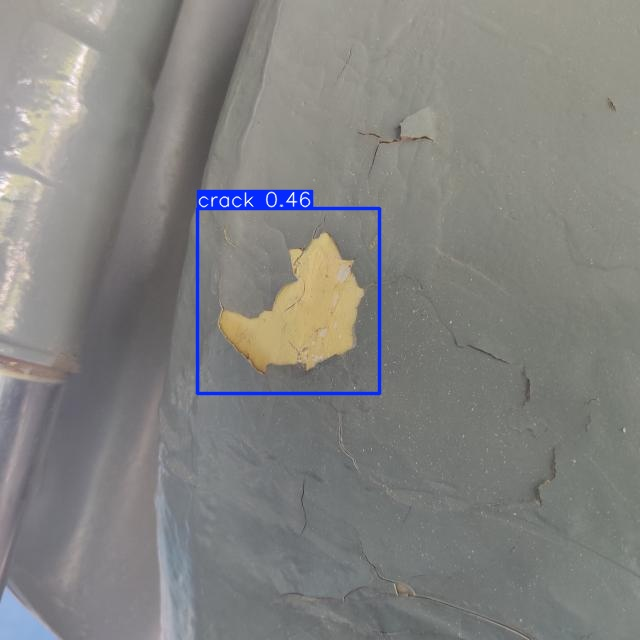

In [14]:
from IPython.display import Image, display

display(Image(filename="/content/runs/detect/predict/aircraft_000000.jpg"))

In [20]:
best_model = YOLO("/content/runs/detect/train-2/weights/best.pt")

In [21]:
best_model.predict(
    source="/content/drive/MyDrive/content/images/train/aircraft_000218.jpg",
    conf=0.25,
    save=True
)


image 1/1 /content/drive/MyDrive/content/images/train/aircraft_000218.jpg: 640x640 1 crack, 10.0ms
Speed: 6.8ms preprocess, 10.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'crack', 1: 'dent', 2: 'corrosion', 3: 'scratch', 4: 'missing-head', 5: 'paint-peel-off'}
 obb: None
 orig_img: array([[[191, 198, 201],
         [191, 198, 201],
         [191, 198, 201],
         ...,
         [181, 193, 195],
         [174, 186, 188],
         [174, 186, 188]],
 
        [[191, 198, 201],
         [191, 198, 201],
         [191, 198, 201],
         ...,
         [182, 194, 196],
         [174, 186, 188],
         [173, 185, 187]],
 
        [[191, 198, 201],
         [191, 198, 201],
         [191, 198, 201],
         ...,
         [183, 195, 197],
         [175, 187, 189],
         [172, 184, 186]],
 
        ...,
 
        [[118, 124, 129],
         [118, 124, 129],
         [119, 125, 130],
         ...,
         [136, 141, 142],
         [136, 141, 142],
         [136, 141, 142]],
 
        [[116, 122, 127],
    

In [23]:
import shutil

shutil.copy(
    "/content/runs/detect/train-2/weights/best.pt",
    "/content/drive/MyDrive/best.pt"
)

'/content/drive/MyDrive/best.pt'

In [25]:
from google.colab import files

files.download("/content/runs/detect/train-2/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>